# ¿Pueden los algoritmos de Machine Learning sustituir a los Modelos Lineales Generalizados en el Modelado de Frecuencia de Siniestros en el sector asegurador de Automóviles?

## - Evidencia desde el Sector Asegurador de Automóviles Francés

Este proyecto utiliza el dataset "French Motor Third-Party Liability Claims" (freMTPL2), un estándar en la industria actuarial y de ciencia de datos para el modelado de riesgos. La base de datos permite la construcción de un motor de tarificación dinámica mediante la separación del riesgo en dos componentes críticos: Frecuencia y Severidad.

1.- Variables de Frecuencia:

* IDpol: Identificador único de la póliza (llave de unión).
* ClaimNb: Número de siniestros registrados (Target para Poisson).
* Exposure: Tiempo de cobertura en años (factor de ajuste de riesgo).
* Area: Zona de residencia (categorizada por densidad).
* VehPower: Potencia fiscal del vehículo (variable ordinal).
* VehAge: Antigüedad del vehículo en años.
* DrivAge: Edad del conductor en años.
* BonusMalus: Historial de bonificación/penalización (100 es el estándar).
* VehBrand: Marca del vehículo (categoría).
* VehGas: Tipo de combustible (Regular/Diesel).
* Density: Densidad poblacional del área de residencia.

2.-Variables de severidad:

* IDpol: Identificador único de la póliza.
* ClaimAmount: Costo total monetario del siniestro (Target para Gamma).

In [30]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [31]:
freq_data = fetch_openml(data_id=41214, as_frame=True, parser='auto')
sev_data = fetch_openml(data_id=41215, as_frame=True,parser='auto')

df_freq = freq_data.frame
df_sev = sev_data.frame

print(f"Dataset de Frecuencia: {df_freq.shape}")
print(f"Dataset de Severidad: {df_sev.shape}")

Dataset de Frecuencia: (678013, 12)
Dataset de Severidad: (26639, 2)


In [32]:
df_freq.head(3)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22


In [33]:
df_sev.head(3)

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11


En este DataSet se aclara que las pólizas que se encuentran en nuestro dataframe de severidad son las que realizaron una reclamación. Uniremos las dos tablas teniendo en cuenta el identificador de póliza (IDpool) y rellenaremos los valores faltantes con una reclamaciones con coste de 0.

In [34]:
df = df_freq.merge(df_sev,  on='IDpol', how='left')
df['ClaimAmount'] = df['ClaimAmount'].fillna(0)
df = df.drop("ClaimAmount",axis=1)
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


Comprobar que no hay nulos

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679513 entries, 0 to 679512
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   IDpol       679513 non-null  float64 
 1   ClaimNb     679513 non-null  int64   
 2   Exposure    679513 non-null  float64 
 3   Area        679513 non-null  category
 4   VehPower    679513 non-null  int64   
 5   VehAge      679513 non-null  int64   
 6   DrivAge     679513 non-null  int64   
 7   BonusMalus  679513 non-null  int64   
 8   VehBrand    679513 non-null  category
 9   VehGas      679513 non-null  object  
 10  Density     679513 non-null  int64   
 11  Region      679513 non-null  category
dtypes: category(3), float64(2), int64(6), object(1)
memory usage: 48.6+ MB


In [36]:
df.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.795130e+05,679513.000000,679513.000000,679513.000000,679513.000000,679513.000000,679513.000000,679513.000000
mean,2.621743e+06,0.058554,0.529078,6.454486,7.043808,45.497617,59.784621,1794.052255
std,1.641757e+06,0.279196,0.364378,2.050990,5.664855,14.140106,15.666953,3960.829098
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157893e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272111e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046210e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


## Visualizar estructura de datos

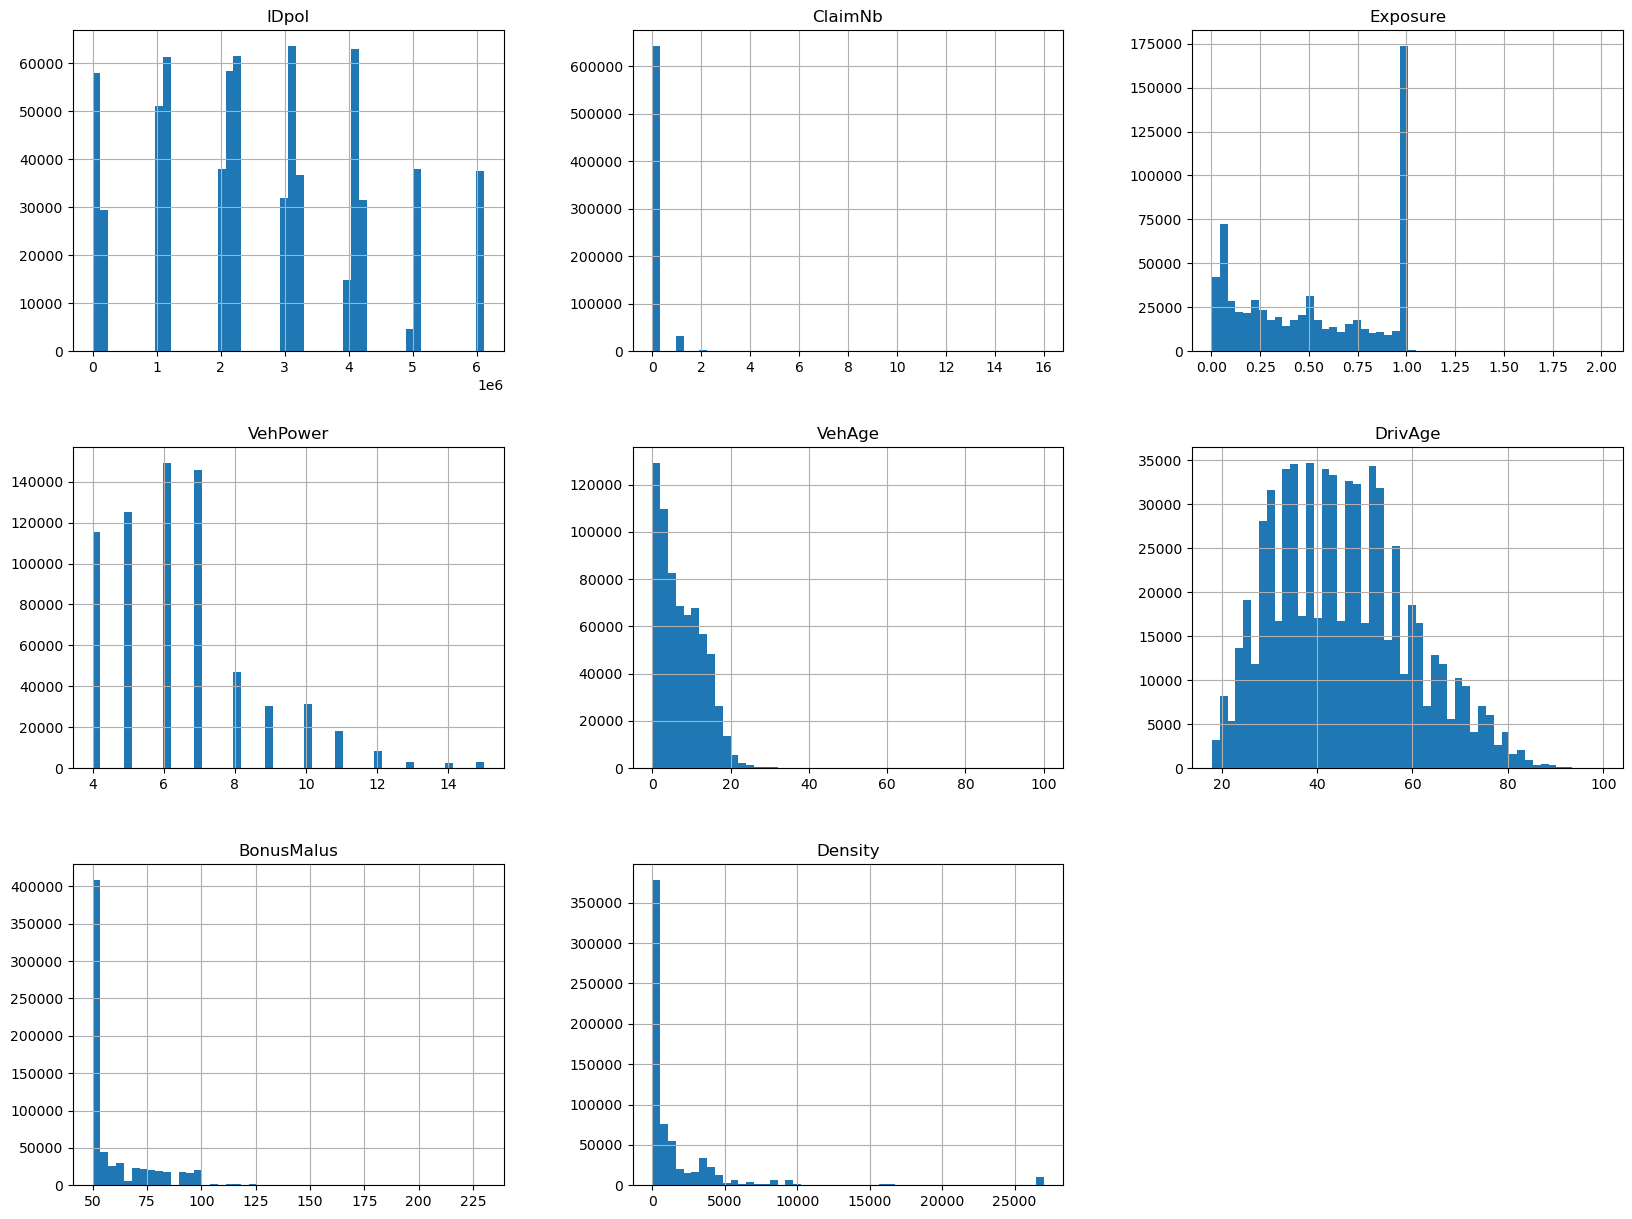

In [37]:
df.hist(bins=50, figsize=(20,15))
plt.show()

* ClaimNb: La barra gigante en el 0 indica que los choques son eventos raros, de vez en cuando alguien reclama una vez y extremadamente pocas veces veces reclaman 2 o más veces.
* ClaimAmount: Parecido a ClaimNb: Pareciera que los costos son 0 siempre, pero como una poliza puede tomar un intervalo de valores, la desproporción de lacantidad de 0 con los demás números los aplasta visualmente.

* Exposure: E pico masivo en 1.0 demuestra que la mayoría de los clientes mantienen su póliza el año completo. los valores menores a 1 son altas tardías o cancelaciones.
* DrivAge: Parece una gráfica normal la cual nos indica que la mayoria de nuestros clientes tienen entre 30 y 50 años
* BonusMalus: El pico masivo está en 50. En el sistema europeo, 50 es la mejor calificación posible. Esto indica que nuestra cartera de clientes está llena de conductores "excelentes" históricamente.
* VehAge y VehPower: Casi por completo todos los vehiculos tienen menos de 20 años, y la gran mayoria tienen menos de 10 años. Los autos tienen una potencia media de entre 4 y 7.
* Densidad: Es una gráfica supersesgada a la izquierda. La inmensa mayoria de las pólizas son de zonas con baja densidad poblacional, y la pequeña cola a la derecha representa a los pocos clientes que viven en zonas de mucho tráfico.   

## Estratificación (Crear un DataTest)

Dado que nuestro dataset presenta un desbalance significativo en la variable objetivo `ClaimNb` (donde la mayoría de las pólizas no presentan siniestros), esta función nos permite implementar una estratificación precisa. Al utilizar el parámetro `stratify=y`, garantizamos que la distribución de siniestralidad se mantenga constante tanto en el conjunto de entrenamiento como en el de prueba, evitando sesgos de selección y asegurando que nuestro modelo sea evaluado bajo condiciones realistas y representativas del riesgo real.

In [38]:
from sklearn.model_selection import train_test_split
X = df.drop("ClaimNb",axis=1)
y = df["ClaimNb"]
strat_X_train, strat_X_test, strat_y_train, strat_y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Proporción en Train:")
print(pd.Series(strat_y_train).value_counts(normalize=True))
print("\nProporción en Test:")
print(pd.Series(strat_y_test).value_counts(normalize=True))

Proporción en Train:
ClaimNb
0     0.947668
1     0.047354
2     0.004536
3     0.000304
11    0.000033
4     0.000033
16    0.000024
5     0.000015
9     0.000013
8     0.000011
6     0.000009
Name: proportion, dtype: float64

Proporción en Test:
ClaimNb
0     0.947669
1     0.047357
2     0.004533
3     0.000302
11    0.000037
4     0.000029
16    0.000022
8     0.000015
9     0.000015
5     0.000015
6     0.000007
Name: proportion, dtype: float64


## Buscar correlaciones

In [39]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["ClaimNb"].sort_values(ascending=False)

ClaimNb       1.000000
Exposure      0.063343
BonusMalus    0.052456
Density       0.011675
DrivAge       0.010298
VehPower     -0.007582
VehAge       -0.016817
IDpol        -0.110348
Name: ClaimNb, dtype: float64

La relación lineal que se genera con correlaciones dice que las mejores variables para  son Exposure y Bonus Malus, esto pordria indicar que el tiempo de exposición al riesgo y el sistema de bonificación son, efectivamente, los factores que más importan en el calculo de la siniestralidad.

## Data Cleaning

### Pipeline de transformación y ColumnTransformer

In [40]:
strat_X_train.head(3)

,IDpol,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
378510,3038353.0,0.29,D,11,0,58,50,B12,'Diesel',698,R11
610520,5033038.0,0.52,D,6,10,62,58,B3,'Diesel',962,R31
60166,129541.0,1.00,D,7,20,63,50,B1,'Regular',741,R24


#### Creación, eliminación y manipulación de categorias + OnehotEncoding

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin

class Cleaning(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cols_to_drop = ['IDpol', 'ClaimNb', 'Exposure', 'ClaimAmount']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_clean = X.copy()
        X_clean = X_clean.drop(columns=self.cols_to_drop, errors='ignore')
        if 'Density' in X_clean.columns:
            X_clean['Density_log'] = np.log1p(X_clean['Density'])
            X_clean = X_clean.drop(columns=['Density'])

        return X_clean

#### Pipeline Numérico

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler 


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_escaler',StandardScaler())
])  

#### Pipeline Completo

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat = ['Area','VehBrand','VehGas','Region']
num = ['VehPower','VehAge','DrivAge','BonusMalus','Density_log']


full_pipeline = Pipeline([
    ('cleaning', Cleaning()),
    ('preproccesing', ColumnTransformer([
        ('num', num_pipeline, num),
        ('cat', OneHotEncoder(drop='first',handle_unknown='ignore', sparse_output=False), cat)
    ])) 
])
strat_X_train_processed = full_pipeline.fit_transform(strat_X_train)
strat_X_test_processed = full_pipeline.transform(strat_X_test)

## Evaluación en modelos Estadísticos y estandares de ML

### GLM con Regresión de Poisson

1. El problema con la regresión tradicional: Para predecir la cantidad de siniestros (ClaimNb), la regresión lineal clásica no nos sirve. Al trazar una línea recta, el modelo podría arrojarnos predicciones negativas (ej. $-1.5$ accidentes), lo cual es actuarialmente imposible.

2. ¿Por qué Poisson?La distribución de Poisson está diseñada matemáticamente para datos de conteo ($0, 1, 2, 3...$) y eventos raros. Su ecuación utiliza una función exponencial $\exp()$ que envuelve a todas las variables predictoras, garantizando que el resultado siempre sea un número mayor o igual a cero.
3. ¿Qué predice exactamente?El modelo no adivina el número exacto de choques de una persona, sino su tasa de riesgo esperada ($\lambda$). A través del algoritmo de Máxima Verosimilitud, encuentra los "pesos" o coeficientes ($\beta$) perfectos para variables como la edad o la potencia del auto. Con esto, el modelo evalúa cada perfil y le asigna una curva de probabilidad única a cada cliente.

#### Estrategia

* 1.- Para cada póliza se calcula un λ distinto usando los betas actuales(el riesgo esperado de esa póliza específica):

        λ = exp(β₀ + β₁·VehPower + β₂·VehAge + ... + β₅·Density_log + log(Exposure).

* 2.- La distribución de Poisson evalúa qué tan probable era observar los siniestros reales dado ese λ.

$$P(k | λ) =  \frac{\lambda^y e^{-\lambda}}{y!}$$

* 3.-Se suman todos esos logaritmos de probabilidad para obtener una puntuación global. 



La función de probabilidad de Poisson original es:$$P(y) = \frac{\lambda^y e^{-\lambda}}{y!}$$
Para poder sumar en lugar de multiplicar evitando que nuestra computadora al multiplicar por valores fraccionarios pierda el valor real, le aplicamos $\ln$ a la fórmula original para encontrar el valor máximo. Por leyes de logaritmos:$$\ln(P(y)) = \ln\left( \frac{\lambda^y e^{-\lambda}}{y!} \right)$$
$$\ln(P(y)) = \ln(\lambda^y) + \ln(e^{-\lambda}) - \ln(y!)$$
$$\ln(P(y)) = y \cdot \ln(\lambda) - \lambda - \ln(y!)$$

* 4.- El algoritmo BFGS mueve los betas en la dirección que sube esa puntuación, y repite hasta que ya no puede mejorar.

In [44]:
import statsmodels.api as sm
from scipy.special import factorial
from scipy.optimize import minimize

X_train_poisson = sm.add_constant(strat_X_train_processed).astype(float)
y_train_poisson = strat_y_train.values.astype(float)

exposure_train = np.maximum(df.loc[strat_X_train.index, 'Exposure'].values, 1e-6)
offset_train = np.log(exposure_train)

def log_likelihood_poisson(betas, X, y, offset):
    lambda_ = np.exp(np.dot(X,betas)+offset)
    # Aplicamos el logaritmo a nuestra función a optimizar
    log_likelihood = np.sum(y *np.log(lambda_+ 1e-10) - lambda_ - np.log(factorial(y)))
    return -log_likelihood

betas_start = np.zeros(X_train_poisson.shape[1])
resultado = minimize(log_likelihood_poisson, x0=betas_start, args = (X_train_poisson,y_train_poisson,offset_train),method='BFGS')

In [45]:
log_likelihood_final = -resultado.fun

n = X_train_poisson.shape[0] # Número de observaciones (clientes)
k = len(resultado.x)         # Número de parámetros (betas)

aic = -2 * log_likelihood_final + 2 * k
bic = -2 * log_likelihood_final + k * np.log(n)

print(f"Log-Likelihood: {log_likelihood_final:.4f}")
print(f"AIC: {aic:.4f}")
print(f"BIC: {bic:.4f}")

Log-Likelihood: -124819.0804
AIC: 249724.1608
BIC: 250206.0182


In [46]:
X_glm = sm.add_constant(strat_X_train_processed).astype(float)
y_glm = strat_y_train.values.astype(float)

exposure_glm = np.maximum(df.loc[strat_X_train.index, 'Exposure'].values, 1e-6)
offset_glm = np.log(exposure_glm)

modelo_poisson = sm.GLM(y_glm, X_glm, family=sm.families.Poisson(), offset=offset_glm)
result_poisson = modelo_poisson.fit()

print(result_poisson.summary()) 

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               543610
Model:                            GLM   Df Residuals:                   543567
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2482e+05
Date:                Sat, 27 Jun 2026   Deviance:                   1.9092e+05
Time:                        14:14:39   Pearson chi2:                 1.76e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01231
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3341      0.047    -50.079      0.0

In [47]:
print(f"AIC Poisson:        {result_poisson.aic:.0f}")

AIC Poisson:        249724


### GLM con Regresión de Binomial Negativa Fase 2

1.- Cálculo de la Media (μ) para cada póliza:
Al igual que en Poisson, calculamos el riesgo esperado (la media) para cada póliza basándonos en sus características:

        λ = exp(β₀ + β₁·VehPower + β₂·VehAge + ... + β₅·Density_log + log(Exposure).

2.- Evaluación con la Binomial Negativa (NB2):
En lugar de Poisson, usamos la función de probabilidad NB2 la cual se deriva de la Poisson pero que incorpora nuestro parámetro de dispersión (α) para ajustar la varianza:

$$P(k | \lambda, \alpha) = \frac{\Gamma(k + \frac{1}{\alpha})}{\Gamma(\frac{1}{\alpha}) \cdot k!} \cdot \left( \frac{1}{1 + \alpha \lambda} \right)^{\frac{1}{\alpha}} \cdot \left( \frac{\alpha \lambda}{1 + \alpha \lambda} \right)^k$$
 
Aquí, la función no solo mira el promedio (μ), sino que admite que la realidad es más dispersa gracias al término α.

3.- Suma global de verosimilitud (Log-Likelihood):
Para evitar el error de multiplicar probabilidades pequeñas, trabajamos con los logaritmos de la función anterior. Al sumar los logaritmos de cada póliza, obtenemos la Puntuación Global (Log-Likelihood) del modelo:

$$\ln(P(k | \lambda, \alpha)) = \ln\left( \frac{\Gamma(k + \frac{1}{\alpha})}{\Gamma(\frac{1}{\alpha}) \cdot k!} \right) + \frac{1}{\alpha} \cdot \ln\left( \frac{1}{1 + \alpha \lambda} \right) + k \cdot \ln\left( \frac{\alpha \lambda}{1 + \alpha \lambda} \right)$$

Esta suma nos da un "termómetro" de qué tan bien explican nuestros parámetros (β y α) la realidad de los datos.

4.- Optimización simultánea (BFGS):
El algoritmo BFGS ahora tiene una tarea más difícil: mueve los β (para mejorar el cálculo de μ) y ajusta el valor de α simultáneamente. Repite el proceso subiendo por la "montaña" de verosimilitud hasta encontrar el punto máximo donde el modelo explica con mayor precisión tanto el promedio como la volatilidad real del riesgo.

In [48]:
X_nb2 = sm.add_constant(strat_X_train_processed.astype(float))
y_nb2 = strat_y_train.values.astype(float)

start_params_discreto = np.append(result_poisson.params, 0.1)

modelo_nb2 = sm.NegativeBinomial(y_nb2, X_nb2, offset=offset_glm)
result_nb2 = modelo_nb2.fit(start_params=start_params_discreto,method="bfgs",maxiter=500,disp=False)

print(result_nb2.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                      y   No. Observations:               543610
Model:               NegativeBinomial   Df Residuals:                   543567
Method:                           MLE   Df Model:                           42
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                 0.02213
Time:                        14:15:22   Log-Likelihood:            -1.2238e+05
converged:                       True   LL-Null:                   -1.2515e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3191      0.052    -44.509      0.000      -2.421      -2.217
x1             0.0045      0.007      0.669      0.504      -0.009       0.018
x2            -0.1994      0.008    -25.714      0.0

#### Resultados de AIC

In [49]:
print(f"AIC Poisson:        {result_poisson.aic:.0f}")
print(f"AIC Binomial Neg:   {result_nb2.aic:.0f}")

AIC Poisson:        249724
AIC Binomial Neg:   244839


Eureca! Vemos que la distribución binomial negativa captura mejor la varianza de nuestros datos, ahora compararemos sus resultados en nuestro conjunto de prueba para ver como se comporta en datos desconocidos.

### RandomForestRegressor

In [65]:
exposure_test = np.maximum(df.loc[strat_X_test.index, 'Exposure'].values, 1e-6)
                           
y_train_rate = strat_y_train.values / exposure_train
y_test_rate  = strat_y_test.values / exposure_test

ruta_modelo = 'random_forest_modelo.pkl'

if os.path.exists(ruta_modelo):
    forest = joblib.load(ruta_modelo)
else:
    forest = RandomForestRegressor(n_estimators=300,
        max_depth=8,
        min_samples_leaf=100,
        random_state=42,
        n_jobs=-1
    )
    forest.fit(strat_X_train_processed,y_train_rate,sample_weight=exposure_train,)
    joblib.dump(forest, ruta_modelo) 
lambda_pred_train_rf = forest.predict(strat_X_train_processed)
lambda_pred_test_rf = forest.predict(strat_X_test_processed)

## DataTest

### GLM

Predecir lambdas por persona:

$$\lambda = e^{(\text{pred\_lineal} + \text{offset})}$$

In [51]:
X_test_nb2 = sm.add_constant(strat_X_test_processed.astype(float))
y_test_nb2 = strat_y_test

exposure_test = np.maximum(df.loc[strat_X_test.index, 'Exposure'].values, 1e-6)
offset_glm_test = np.log(exposure_test)

linear_pred_train = modelo_nb2.predict(params=result_nb2.params, exog=X_nb2, which='linear')
lambda_prediction_train = np.exp(linear_pred_train + offset_glm)

linear_pred_test = modelo_nb2.predict(params=result_nb2.params, exog=X_test_nb2, which='linear')
lambda_prediction_test = np.exp(linear_pred_test + offset_glm_test)

In [ ]:
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error, d2_tweedie_score

frecuencia_media = df['ClaimNb'].sum() / df['Exposure'].sum()
dev_train = mean_poisson_deviance(y_nb2, lambda_prediction_train)
dev_test  = mean_poisson_deviance(y_test_nb2,  lambda_prediction_test)

mae      = mean_absolute_error(y_test_nb2, lambda_prediction_test)
r2_modelo   = d2_tweedie_score(y_test_nb2, lambda_prediction_test, power=1)

reales    = int(y_test_nb2.sum())
predichos = int(lambda_prediction_test.sum())

print(f"Deviance en entrenamiento y prueba:{dev_train:.4f}-{dev_test:.4f}")
print(f"MAE prueba:                        {mae:.4f}")
print(f"R² baseline vs prueba:             {r2_modelo:.4f}")
print(f"Siniestros reales vs predichos:    {reales} y {predichos}  ratio: {predichos/reales}")

Deviance en entrenamiento y prueba:0.3514-0.3501
MAE prueba:                        0.1100
R² baseline vs prueba:             0.0071
Siniestros reales vs predichos:    7960 y 8256  ratio: 1.0371859296482413


#### RandomForest(ML)

In [53]:
pred_train_rf = lambda_pred_train_rf * exposure_train
pred_test_rf  = lambda_pred_test_rf * exposure_test

dev_train_rf = mean_poisson_deviance(strat_y_train, np.maximum(pred_train_rf, 1e-6))
dev_test_rf  = mean_poisson_deviance(strat_y_test,  np.maximum(pred_test_rf, 1e-6))

mae_rf = mean_absolute_error(strat_y_test, pred_test_rf)
r2_rf  = d2_tweedie_score(strat_y_test, np.maximum(pred_test_rf, 1e-6), power=1)

reales_rf    = int(strat_y_test.sum())  
predichos_rf = int(pred_test_rf.sum())

print(f"Deviance RF entrenmiento y prueba: {dev_train_rf:.4f} / {dev_test_rf:.4f}")
print(f"MAE RF:                 {mae_rf:.4f}")
print(f"R2 RF:                  {r2_rf:.4f}")
print(f"Ratio RF (pred/real):   {reales_rf}-{predichos_rf} ratio: {predichos_rf/reales_rf}")

Deviance RF entrenmiento y prueba: 0.3260 / 0.3264
MAE RF:                 0.1054
R2 RF:                  0.0746
Ratio RF (pred/real):   7960-7985 ratio: 1.0031407035175879


#### Comparación de Feature Importance

Calculamos importancias y parametros para comparar que variables fueron las más importantes en cada modelo para predecir

In [54]:
names = full_pipeline.named_steps['preproccesing'].get_feature_names_out()
rf_importances = forest.feature_importances_
glm_params = result_nb2.params[1:-1]
glm_params = np.abs(glm_params)

In [ ]:
df_rf_importances = pd.DataFrame({
    'Feature': names,
    'Rf_Importance': rf_importances,
}).sort_values('Rf_Importance', ascending=False).reset_index(drop=True)
df_rf_importances[:10]

,Feature,Rf_Importance
0,num__VehAge,0.397425
1,num__VehPower,0.163570
2,num__BonusMalus,0.130541
3,num__Density_log,0.074292
4,cat__VehBrand_B12,0.060575
5,cat__Area_D,0.057788
6,cat__VehGas_'Regular',0.053417
7,num__DrivAge,0.045608
8,cat__Region_R91,0.007159
9,cat__Region_R82,0.001777


In [ ]:
df_glm_importances = pd.DataFrame({
    'Feature': names,
    'GLM_Params':glm_params,
}).sort_values('GLM_Params', ascending=False).reset_index(drop=True)
df_glm_importances[:10]

,Feature,GLM_Params
0,cat__Region_R91,0.396251
1,num__BonusMalus,0.360804
2,cat__Region_R41,0.301151
3,cat__Region_R83,0.263520
4,cat__VehBrand_B14,0.238723
5,cat__Region_R21,0.233224
6,cat__Region_R74,0.206988
7,cat__Area_D,0.201419
8,num__VehAge,0.199431
9,cat__Region_R94,0.182144


BonusMalus es la variable más relevante en ambos modelos, confirmando que el historial del conductor es el predictor más sólido de siniestralidad coherente con el diseño del sistema Francés.
Más allá de esa coincidencia, cada modelo prioriza de forma distinta porque miden "importancia" de manera diferente. El GLM le asigna un coeficiente independiente a cada categoría de Region, lo que le permite detectar que algunas regiones específicas (R91, R94) tienen riesgo consistentemente más alto que el promedio, y otras (R41, R83) consistentemente más bajo. El Random Forest, mide cuánto reduce el error cada variable al dividir los datos considerando todas las pólizas a la vez, por lo que prioriza VehAge, que separa bien el riesgo de forma general en todo el dataset, sin necesidad de aislar regiones específicas.

## Conclusiones

Este proyecto buscó responder si los algoritmos de Machine Learning pueden sustituir a los Modelos Lineales Generalizados en el modelado de frecuencia de siniestros automotrices. La evidencia recolectada apunta a una respuesta matizada: no sustituyen, pero sí logran un desempeño comparable.

**Sobre el desempeño predictivo:** El modelo Poisson inicial mostró sobredispersión baste significativa, lo cual llevó a adoptar la Binomial Negativa como modelo de referencia, mejorando el AIC de 249,724 a 244,839. Para evitar el sesgo en el sobreajuste inicial y el sesgo sistemático en el Random Forest mostró se ponderó la importancia de caunto tiempo se tuvo datos acerca de la póliza(mediante sample_weight), alcanzó métricas de prueba muy similares a NB2: Deviance de 0.326 frente a 0.350, y un ratio predicho/real de 1.003 frente a 1.037. En términos de capacidad predictiva pura, ningún modelo superó claramente al otro. Aquí es donde la diferencia se vuelve decisiva. NB2 entrega coeficientes directamente interpretables: cada variable tiene un efecto cuantificable y con signo claro sobre la tasa de siniestralidad, lo que permite justificar una prima ante un regulador o un cliente. Random Forest, en cambio, entrega una medida de importancia relativa, pero no explica la dirección ni la magnitud exacta del efecto sin herramientas adicionales (como SHAP).

**Puntos importantes:** La comparación de feature importance mostró que ambos coinciden en que BonusMalus es el predictor más fuerte, asi que podemos decir que el diseño del sistema Bonus-Malus es correto. Aparte de eso el GLM destacó efectos geográficos específicos (algunas regiones con riesgo consistentemente distinto al promedio), mientras que Random Forest priorizó VehAge, sugiriendo una posible relación no lineal que el modelo lineal no captura completamente.

**Respuesta final:** Para este conjunto de datos, los algoritmos de Machine Learning no demuestran una ventaja predictiva suficiente para justificar reemplazar a los GLM, especialmente considerando que estos ofrecen datos interpretables y ya regulados por normas. Sin embargo, Random Forest sí demuestra ser una herramienta valiosa de diagnóstico: su capacidad de capturar relaciones no lineales (como en VehAge) puede usarse para identificar dónde el GLM podría beneficiarse de transformaciones que el GLM aún no tiene en cuenta, en lugar de sustituirlo por completo.